# MIRA & TARP Analysis — SigmaDock vs DiffDock

Evaluates and compares the **pose distribution calibration** of SigmaDock and DiffDock using two complementary metrics:

- **MIRA** (Sharief et al. 2026): posterior calibration score. Perfect = `mira_null(S=40) = 0.6833`. Below = mode-collapsed, above = over-dispersed.
- **TARP** (Lemos et al. 2023): coverage test via Expected Coverage Probability (ECP) curve. ECP above diagonal = over-dispersed; below = mode-collapsed.

> **Dataset note:** SigmaDock results are from the **PoseBusters benchmark** (308 complexes).  
> DiffDock results are from the **PDBBind test set** (322 complexes).  
> Both use S=40 pose samples per complex.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../../DiffDock'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

from utils.tarp_eval import ecp_from_fractions, bootstrap_ecp, plot_ecp
from utils.mira_eval import mira_null

MIRA_REF = mira_null(40)
print(f'MIRA reference (S=40): {MIRA_REF:.4f}')

MIRA reference (S=40): 0.6833


## 1. Load data

In [2]:
SD_NPZ    = '/home/qf226/rds/hpc-work/results/SigmaDock/sigmadock_pb_308/mira_tarp.npz'
DD_METRICS = '/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/metrics'

# ── SigmaDock ─────────────────────────────────────────────────────────────────
sd = np.load(SD_NPZ, allow_pickle=True)
sd_mira_scores  = sd['mira_scores']          # (308,)
sd_tarp_f       = sd['tarp_f_matrix']        # (308, 100)
sd_ecp          = sd['tarp_ecp']             # (50,)  — precomputed
sd_alpha        = sd['tarp_alpha']           # (50,)
sd_boot_ecps    = sd['tarp_boot_ecps']       # (200, 50)

# ── DiffDock ──────────────────────────────────────────────────────────────────
dd_mira_scores  = np.load(f'{DD_METRICS}/mira_scores.npy')              # (322,)
dd_tarp_f       = np.load(f'{DD_METRICS}/tarp_fractions_centroid.npy')  # (322, 100)
dd_ecp, dd_alpha = ecp_from_fractions(dd_tarp_f)
dd_boot_ecps     = bootstrap_ecp(dd_tarp_f, n_bootstrap=200)

print(f'SigmaDock  — N={len(sd_mira_scores):3d}  MIRA mean={sd_mira_scores.mean():.4f}  TARP AUC={np.trapz(sd_ecp, sd_alpha):.4f}')
print(f'DiffDock   — N={len(dd_mira_scores):3d}  MIRA mean={dd_mira_scores.mean():.4f}  TARP AUC={np.trapz(dd_ecp, dd_alpha):.4f}')
print(f'Reference             MIRA ref ={MIRA_REF:.4f}  TARP AUC=0.5000')

SigmaDock  — N=308  MIRA mean=0.6548  TARP AUC=0.5020
DiffDock   — N=322  MIRA mean=0.6188  TARP AUC=0.5150
Reference             MIRA ref =0.6833  TARP AUC=0.5000


## 2. SigmaDock — TARP ECP curve

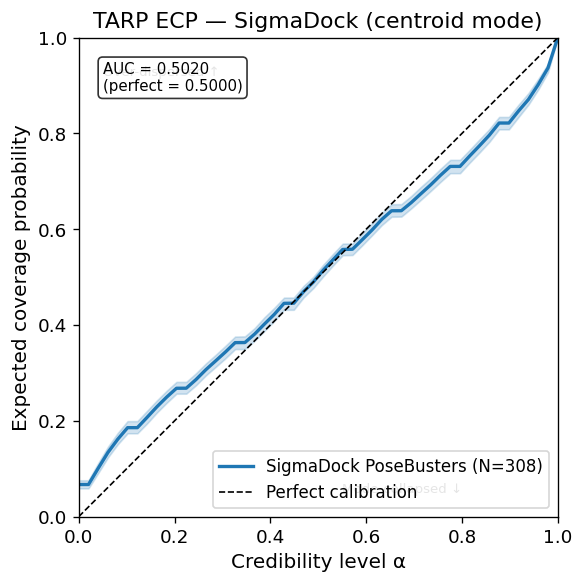

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(sd_ecp, sd_alpha, ax=ax,
         label=f'SigmaDock PoseBusters (N={len(sd_mira_scores)})',
         bootstrap_ecps=sd_boot_ecps)
ax.set_title('TARP ECP — SigmaDock (centroid mode)')
auc = np.trapz(sd_ecp, sd_alpha)
ax.text(0.05, 0.95, f'AUC = {auc:.4f}\n(perfect = 0.5000)',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
fig.tight_layout()
plt.show()

## 3. SigmaDock — MIRA score distribution

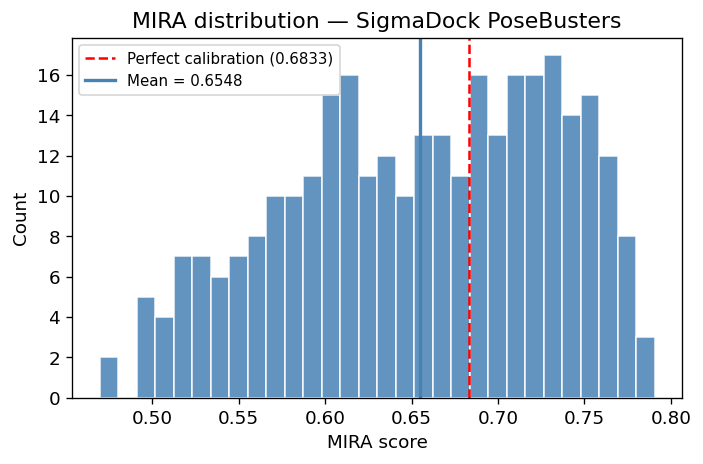

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sd_mira_scores, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MIRA_REF, color='red',   lw=1.5, ls='--', label=f'Perfect calibration ({MIRA_REF:.4f})')
ax.axvline(sd_mira_scores.mean(), color='steelblue', lw=2, label=f'Mean = {sd_mira_scores.mean():.4f}')
ax.set_xlabel('MIRA score')
ax.set_ylabel('Count')
ax.set_title('MIRA distribution — SigmaDock PoseBusters')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. SigmaDock vs DiffDock — side-by-side comparison

> **Note:** Different benchmarks — PoseBusters (SigmaDock) vs PDBBind test set (DiffDock). Comparison is illustrative.

Saved → /home/qf226/rds/hpc-work/results/SigmaDock/sigmadock_pb_308/mira_tarp_comparison.png


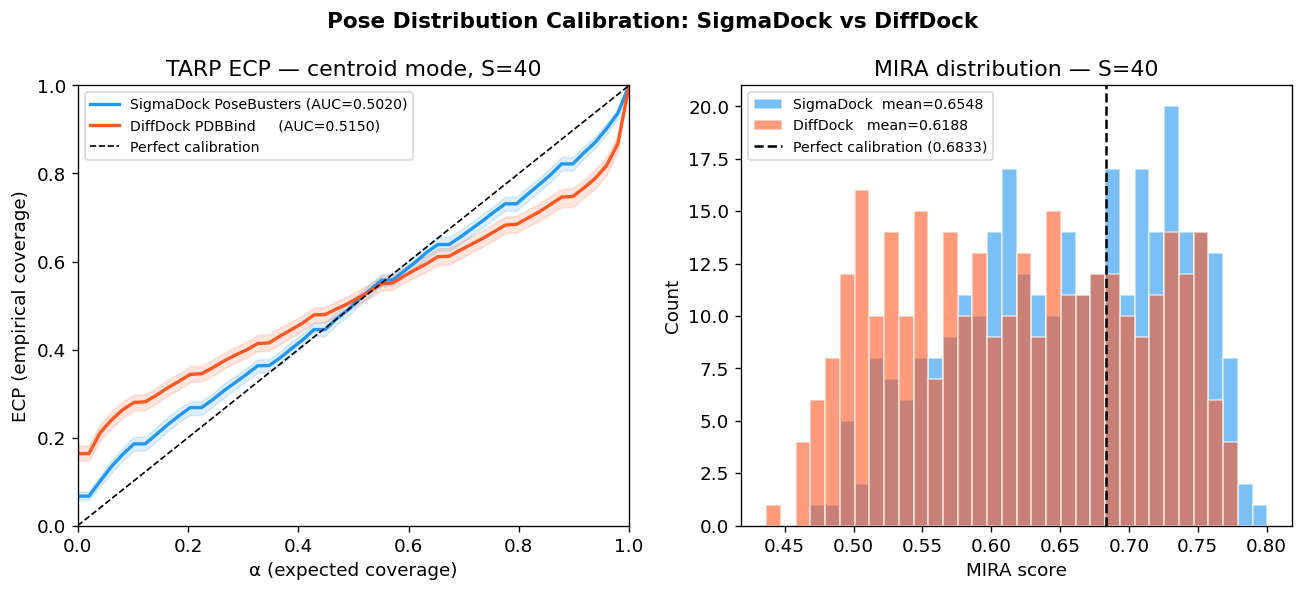

In [5]:
SD_COLOUR = '#2196F3'   # blue
DD_COLOUR = '#FF5722'   # orange-red

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ── Left: TARP ECP curves ──────────────────────────────────────────────────────
ax = axes[0]

def _fill_boot(ax, alpha, boot_ecps, color):
    lo = np.percentile(boot_ecps, 2.5, axis=0)
    hi = np.percentile(boot_ecps, 97.5, axis=0)
    ax.fill_between(alpha, lo, hi, color=color, alpha=0.15)

_fill_boot(ax, sd_alpha, sd_boot_ecps, SD_COLOUR)
_fill_boot(ax, dd_alpha, dd_boot_ecps, DD_COLOUR)

ax.plot(sd_alpha, sd_ecp, color=SD_COLOUR, lw=2,
        label=f'SigmaDock PoseBusters (AUC={np.trapz(sd_ecp, sd_alpha):.4f})')
ax.plot(dd_alpha, dd_ecp, color=DD_COLOUR, lw=2,
        label=f'DiffDock PDBBind     (AUC={np.trapz(dd_ecp, dd_alpha):.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')

ax.set_xlabel('α (expected coverage)')
ax.set_ylabel('ECP (empirical coverage)')
ax.set_title('TARP ECP — centroid mode, S=40')
ax.legend(fontsize=8.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── Right: MIRA distributions ─────────────────────────────────────────────────
ax = axes[1]
bins = np.linspace(
    min(sd_mira_scores.min(), dd_mira_scores.min()) - 0.01,
    max(sd_mira_scores.max(), dd_mira_scores.max()) + 0.01,
    35,
)
ax.hist(sd_mira_scores, bins=bins, color=SD_COLOUR, alpha=0.6, edgecolor='white',
        label=f'SigmaDock  mean={sd_mira_scores.mean():.4f}')
ax.hist(dd_mira_scores, bins=bins, color=DD_COLOUR, alpha=0.6, edgecolor='white',
        label=f'DiffDock   mean={dd_mira_scores.mean():.4f}')
ax.axvline(MIRA_REF, color='black', lw=1.5, ls='--',
           label=f'Perfect calibration ({MIRA_REF:.4f})')
ax.set_xlabel('MIRA score')
ax.set_ylabel('Count')
ax.set_title('MIRA distribution — S=40')
ax.legend(fontsize=8.5)

fig.suptitle('Pose Distribution Calibration: SigmaDock vs DiffDock', fontsize=13, fontweight='bold')
fig.tight_layout()

out_path = '/home/qf226/rds/hpc-work/results/SigmaDock/sigmadock_pb_308/mira_tarp_comparison.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved → {out_path}')
plt.show()

## 5. Summary table

In [6]:
sd_auc = np.trapz(sd_ecp, sd_alpha)
dd_auc = np.trapz(dd_ecp, dd_alpha)

sd_dev = sd_mira_scores.mean() - MIRA_REF
dd_dev = dd_mira_scores.mean() - MIRA_REF

def calibration_label(dev):
    if abs(dev) < 0.005: return 'well-calibrated'
    return 'mode-collapsed' if dev < 0 else 'over-dispersed'

print(f"{'':20s} {'SigmaDock':>14s} {'DiffDock':>14s} {'Reference':>14s}")
print('-' * 64)
print(f"{'Dataset':20s} {'PoseBusters':>14s} {'PDBBind':>14s} {'—':>14s}")
print(f"{'N complexes':20s} {len(sd_mira_scores):>14d} {len(dd_mira_scores):>14d} {'—':>14s}")
print(f"{'MIRA mean':20s} {sd_mira_scores.mean():>14.4f} {dd_mira_scores.mean():>14.4f} {MIRA_REF:>14.4f}")
print(f"{'MIRA deviation':20s} {sd_dev:>+14.4f} {dd_dev:>+14.4f} {'0.0000':>14s}")
print(f"{'MIRA label':20s} {calibration_label(sd_dev):>14s} {calibration_label(dd_dev):>14s} {'perfect':>14s}")
print(f"{'TARP AUC':20s} {sd_auc:>14.4f} {dd_auc:>14.4f} {'0.5000':>14s}")
print(f"{'ECP @ α=0.5':20s} {np.interp(0.5, sd_alpha, sd_ecp):>14.3f} {np.interp(0.5, dd_alpha, dd_ecp):>14.3f} {'0.500':>14s}")

                          SigmaDock       DiffDock      Reference
----------------------------------------------------------------
Dataset                 PoseBusters        PDBBind              —
N complexes                     308            322              —
MIRA mean                    0.6548         0.6188         0.6833
MIRA deviation              -0.0285        -0.0646         0.0000
MIRA label           mode-collapsed mode-collapsed        perfect
TARP AUC                     0.5020         0.5150         0.5000
ECP @ α=0.5                   0.502          0.511          0.500
